<a href="https://colab.research.google.com/github/greeshmakrishnan00/EDA-ML-DL-Projects/blob/main/AI_BASED_STUDENT_PERFORMANCE_PREDICTION_SYSTEM_PROJECT_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem statement

Educational institutions often face challenges in monitoring the academic progress of students and identifying those who may be at risk of poor performance. Traditional methods of evaluation usually rely on periodic examinations and manual observation, which may not provide timely insights into a student's learning difficulties. As a result, students who require additional academic support may go unnoticed until their performance declines significantly. This can lead to lower academic achievement, increased dropout rates, and reduced overall educational effectiveness.

With the growing availability of student-related data such as attendance records, internal assessment scores, previous semester grades, study habits, participation in extracurricular activities, and socio-economic factors, there is an opportunity to leverage Artificial Intelligence and Machine Learning techniques to predict student performance in advance. By analyzing historical academic and behavioral data, an AI-based Student Performance Prediction System can identify patterns and factors that influence academic success or failure. The system can classify students into performance categories, helping educators take proactive measures, provide personalized guidance, and implement timely interventions to improve learning outcomes and overall student success.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv("/content/Student_Performance_100K_20Columns.csv")
df

,Student_ID,Gender,Age,Attendance_Percentage,Internal_Assessment_Marks,Midterm_Exam_Marks,Assignment_Score,Previous_Semester_Grade,Study_Hours_Per_Day,Participation_In_Activities,Internet_Access,Parent_Education_Level,Family_Income_Level,Socio_Economic_Status,Sleep_Hours,Screen_Time_Hours,Distance_From_College_KM,Class_Participation_Score,Scholarship_Status,Performance_Category
0,S000001,Male,22,90.8,49.6,91.9,56.8,A,4.1,High,Yes,School,Low,Low,6.6,3.9,16.1,96.8,No,Good
1,S000002,Female,24,62.3,66.8,65.9,57.4,C,3.6,High,Yes,Diploma,Low,Low,4.8,5.4,7.9,73.0,No,Good
2,S000003,Female,21,84.7,45.4,61.1,80.8,A,0.0,High,No,Graduate,Middle,Middle,8.7,1.9,19.8,74.8,No,Good
3,S000004,Male,20,78.1,73.5,65.5,78.7,A,0.0,Medium,Yes,Diploma,High,High,7.1,5.4,14.2,48.8,Yes,Good
4,S000005,Male,17,100.0,62.0,54.6,81.6,A,6.2,High,Yes,Graduate,High,High,6.3,2.0,1.0,79.6,Yes,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,S099996,Female,21,85.6,76.6,43.4,64.2,A,6.5,High,Yes,Diploma,Middle,Middle,6.1,3.2,5.7,56.0,Yes,Good
99996,S099997,Male,19,84.1,59.1,64.6,85.9,B,3.7,Low,Yes,Postgraduate,High,High,4.7,2.8,22.7,79.6,No,Good
99997,S099998,Female,17,78.9,66.5,69.0,59.1,F,2.3,Medium,Yes,Graduate,High,High,8.8,4.9,13.4,47.0,Yes,Poor
99998,S099999,Male,24,52.8,88.6,67.3,67.2,A,3.4,Medium,Yes,Diploma,High,High,4.3,1.3,4.4,65.3,No,Good


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
Attendance_Percentage,0
Internal_Assessment_Marks,0
Midterm_Exam_Marks,0
Assignment_Score,0
Previous_Semester_Grade,0
Study_Hours_Per_Day,0
Participation_In_Activities,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(100000, 20)

In [ ]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Study_Hours_Per_Day',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Socio_Economic_Status', 'Sleep_Hours', 'Screen_Time_Hours',
       'Distance_From_College_KM', 'Class_Participation_Score',
       'Scholarship_Status', 'Performance_Category'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  object 
 1   Gender                       100000 non-null  object 
 2   Age                          100000 non-null  int64  
 3   Attendance_Percentage        100000 non-null  float64
 4   Internal_Assessment_Marks    100000 non-null  float64
 5   Midterm_Exam_Marks           100000 non-null  float64
 6   Assignment_Score             100000 non-null  float64
 7   Previous_Semester_Grade      100000 non-null  object 
 8   Study_Hours_Per_Day          100000 non-null  float64
 9   Participation_In_Activities  100000 non-null  object 
 10  Internet_Access              100000 non-null  object 
 11  Parent_Education_Level       100000 non-null  object 
 12  Family_Income_Level          100000 non-null  object 
 13  

In [ ]:
target="Performance_Category"

In [ ]:
df[target].value_counts()

,count
Performance_Category,
Good,97352
Poor,2648


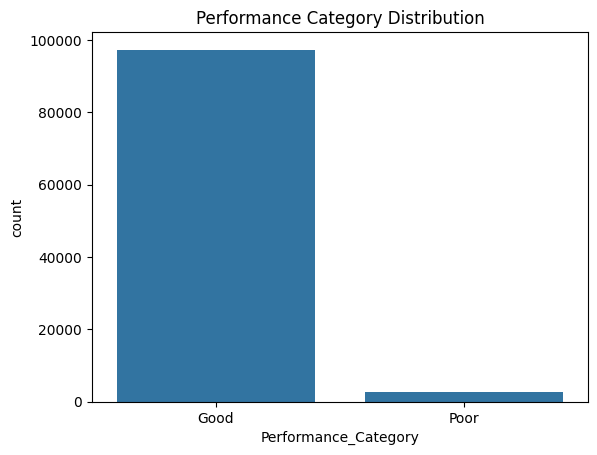

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Performance_Category",data=df)
plt.title("Performance Category Distribution")
plt.show()

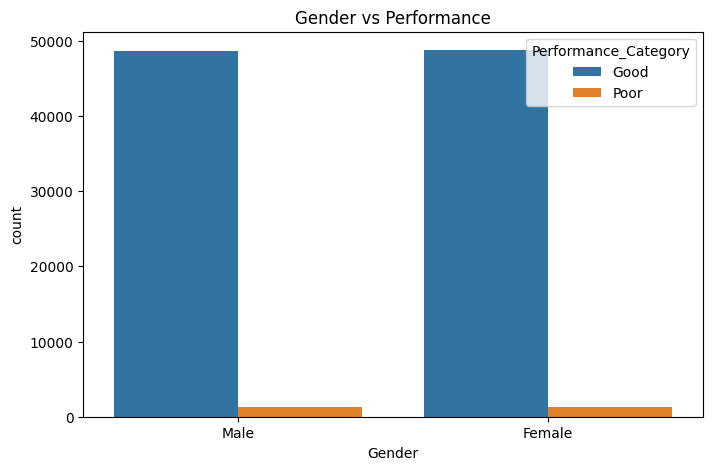

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Gender',
              hue='Performance_Category',
              data=df)

plt.title('Gender vs Performance')
plt.show()

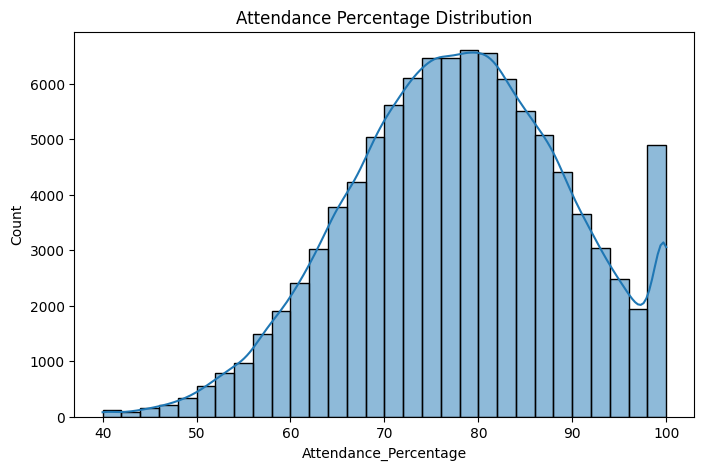

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Attendance_Percentage'],
             bins=30,
             kde=True)

plt.title('Attendance Percentage Distribution')
plt.show()

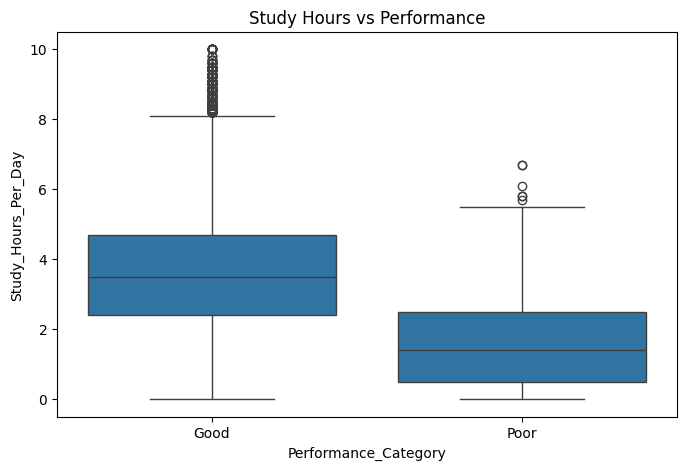

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Performance_Category',
            y='Study_Hours_Per_Day',
            data=df)

plt.title('Study Hours vs Performance')
plt.show()

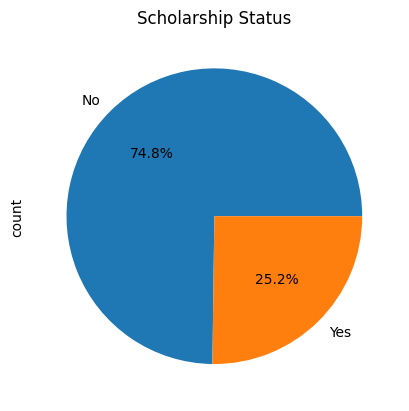

In [ ]:
df['Scholarship_Status'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Scholarship Status')
plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include="object").columns
categorical_cols

Index(['Student_ID', 'Gender', 'Previous_Semester_Grade',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level',
       'Socio_Economic_Status', 'Scholarship_Status', 'Performance_Category'],
      dtype='object')

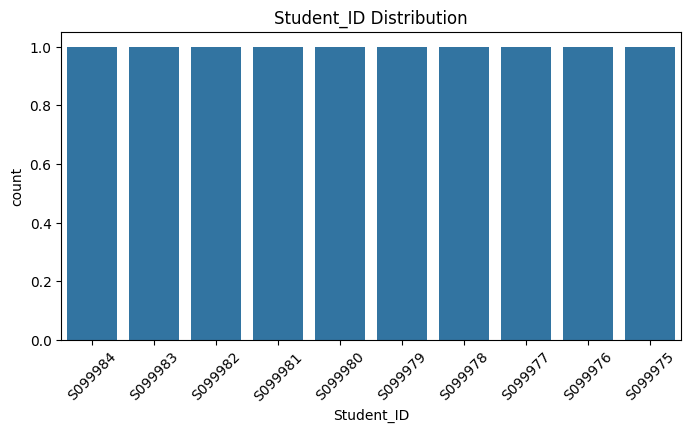

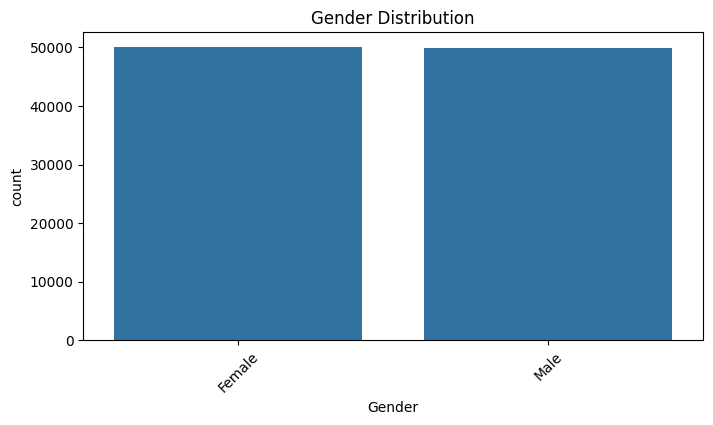

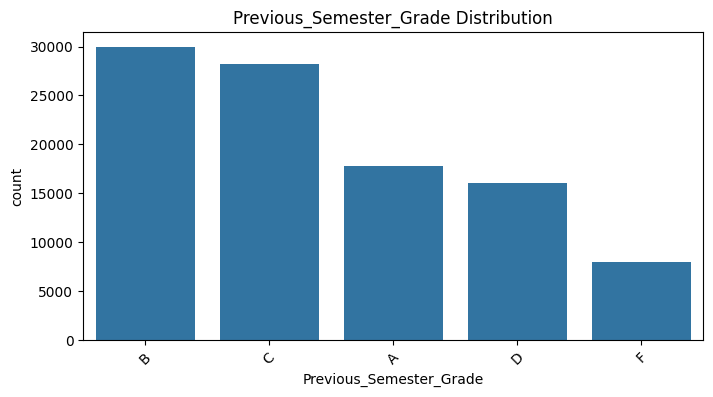

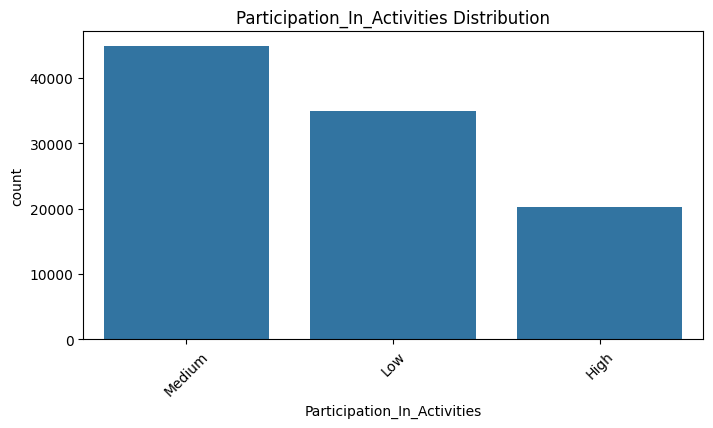

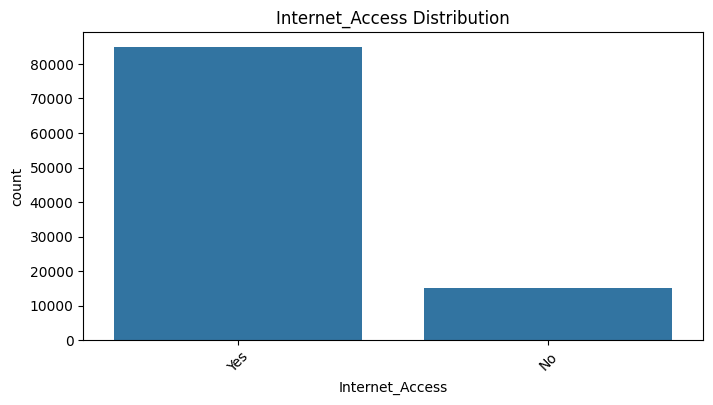

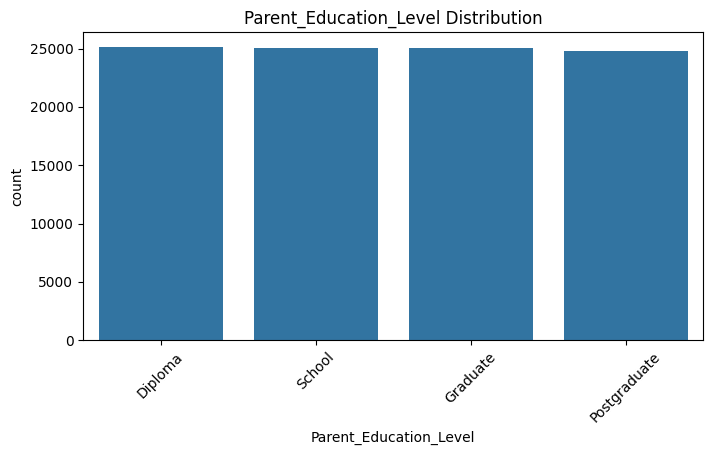

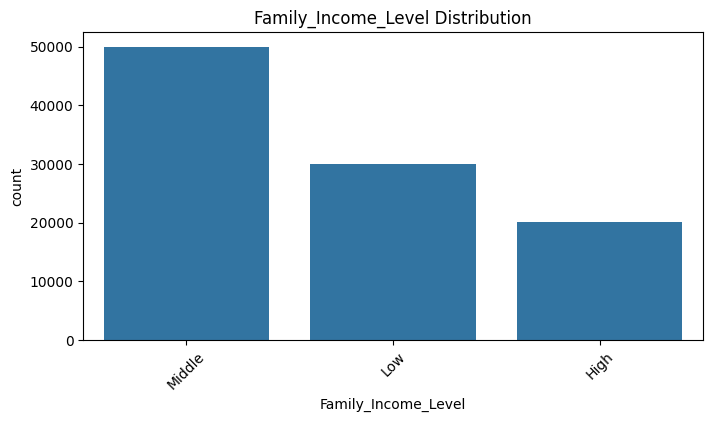

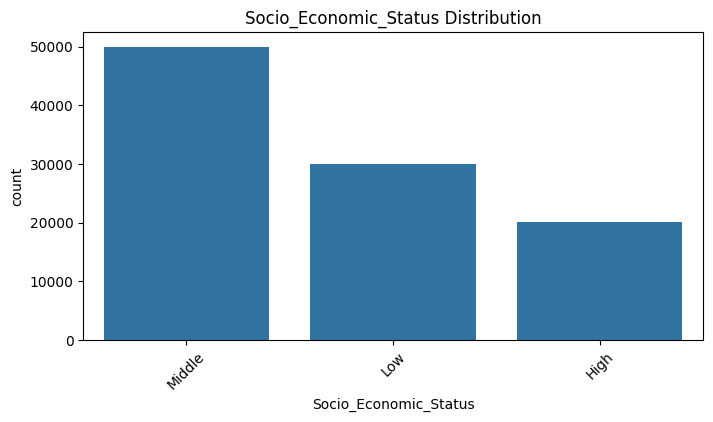

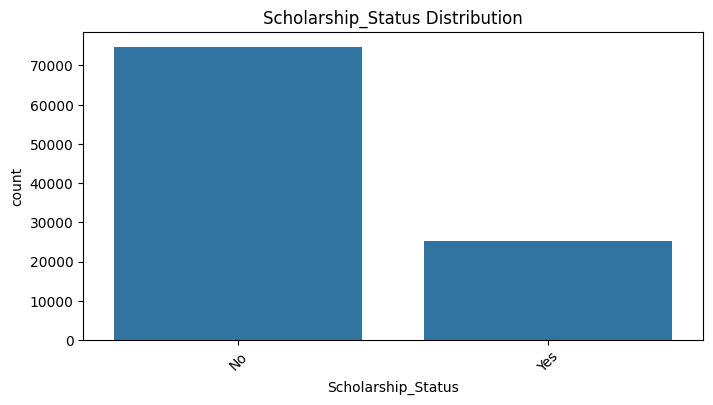

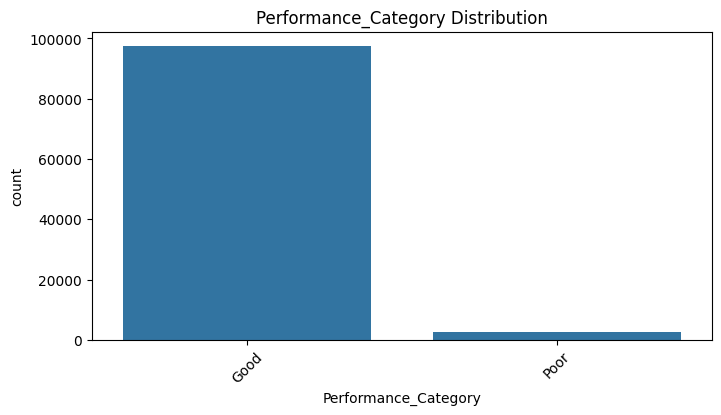

In [ ]:
for col in categorical_cols:
  plt.figure(figsize=(8,4))
  sns.countplot(x=df[col],order=df[col].value_counts().index[:10])
  plt.xticks(rotation=45)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['Age', 'Attendance_Percentage', 'Internal_Assessment_Marks',
       'Midterm_Exam_Marks', 'Assignment_Score', 'Study_Hours_Per_Day',
       'Sleep_Hours', 'Screen_Time_Hours', 'Distance_From_College_KM',
       'Class_Participation_Score'],
      dtype='object')

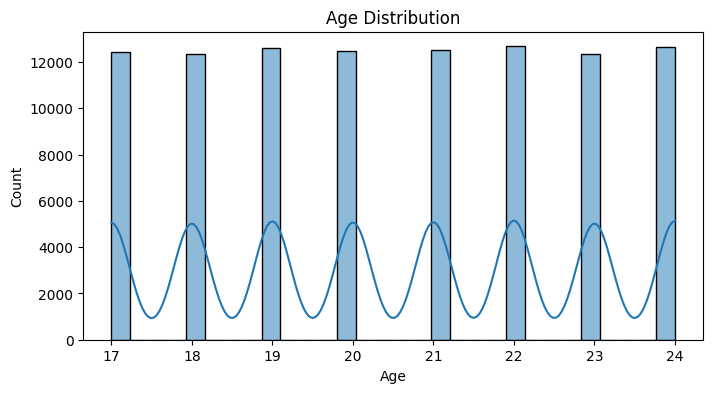

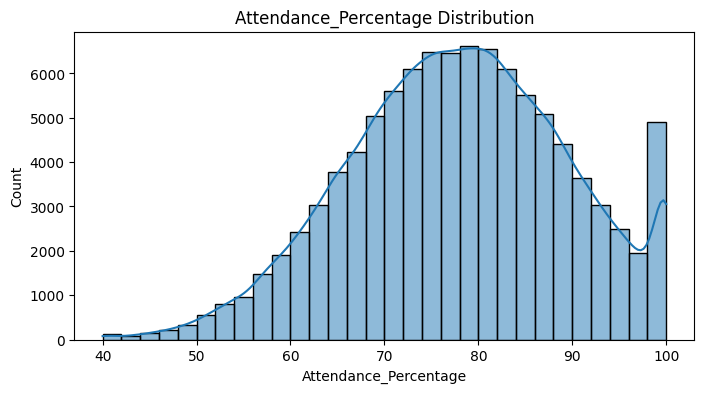

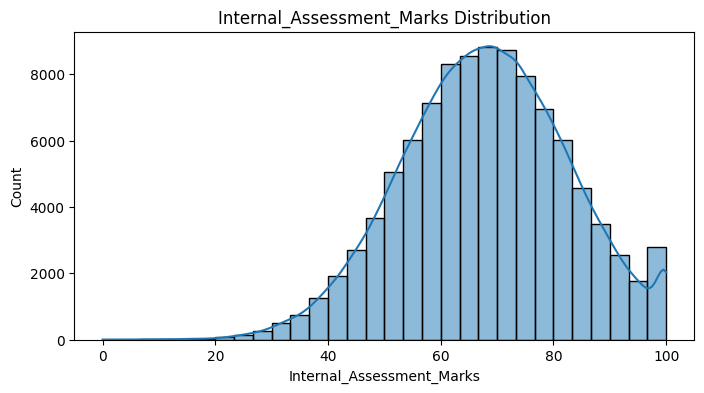

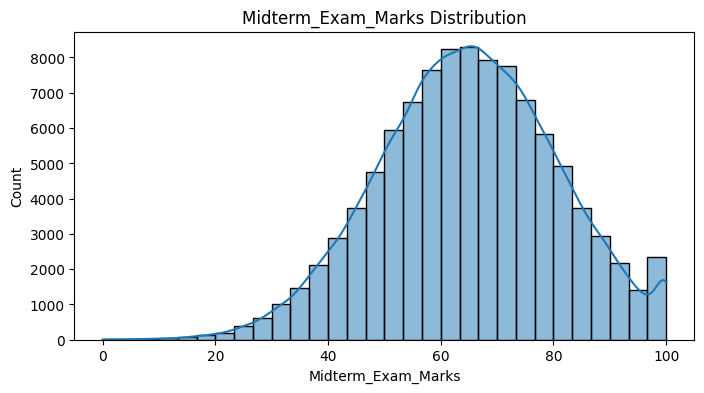

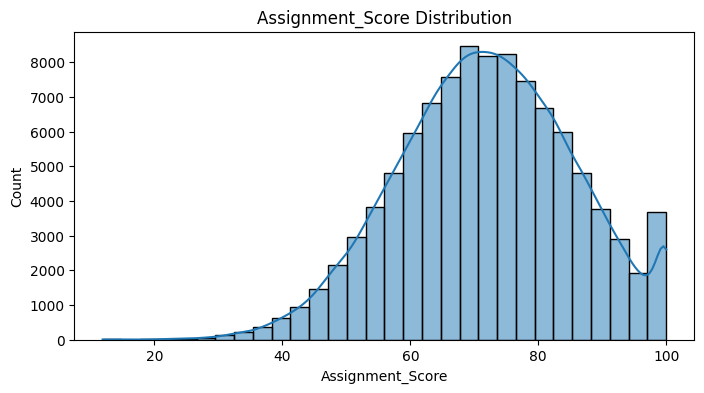

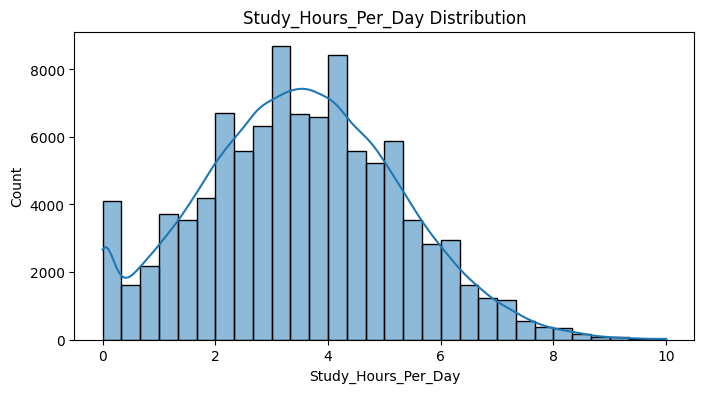

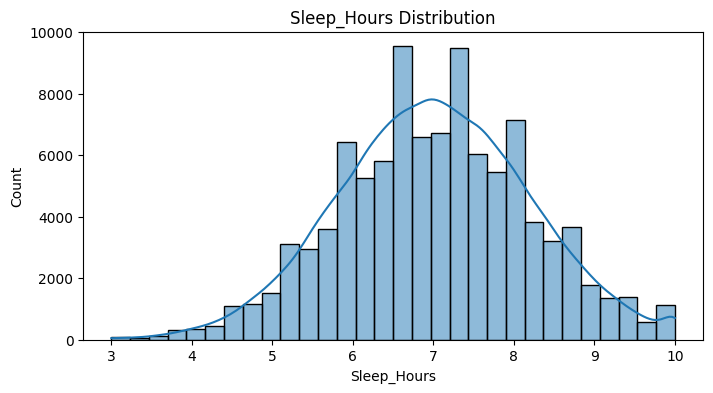

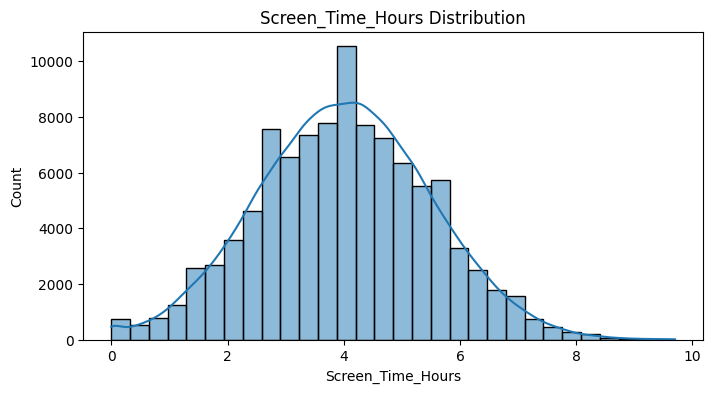

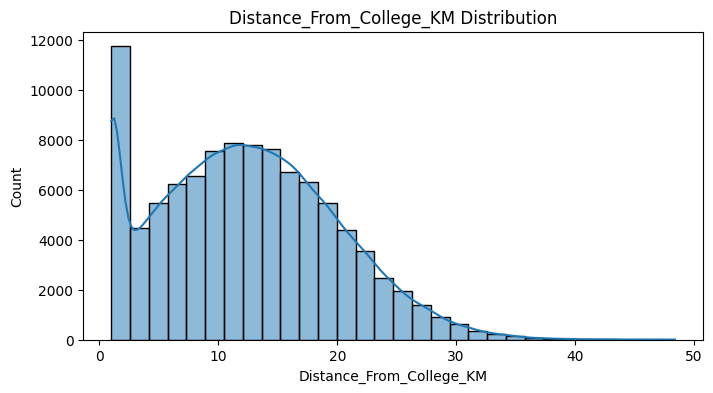

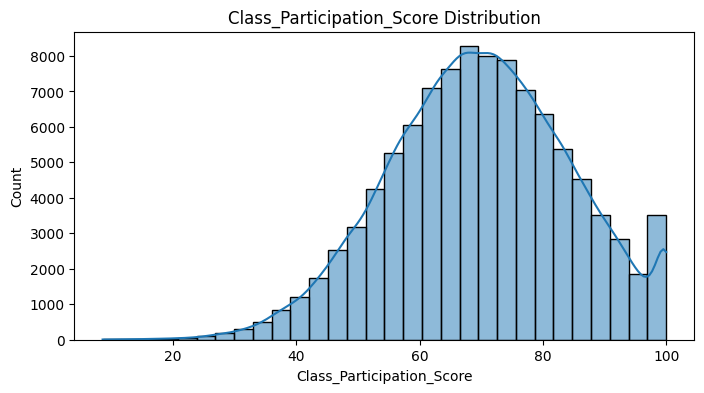

In [ ]:
for col in numeric_cols:
  plt.figure(figsize=(8,4))
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(f'{col} Distribution')
  plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  object 
 1   Gender                       100000 non-null  object 
 2   Age                          100000 non-null  int64  
 3   Attendance_Percentage        100000 non-null  float64
 4   Internal_Assessment_Marks    100000 non-null  float64
 5   Midterm_Exam_Marks           100000 non-null  float64
 6   Assignment_Score             100000 non-null  float64
 7   Previous_Semester_Grade      100000 non-null  object 
 8   Study_Hours_Per_Day          100000 non-null  float64
 9   Participation_In_Activities  100000 non-null  object 
 10  Internet_Access              100000 non-null  object 
 11  Parent_Education_Level       100000 non-null  object 
 12  Family_Income_Level          100000 non-null  object 
 13  

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Student_ID"]=le.fit_transform(df["Student_ID"])
df["Gender"]=le.fit_transform(df["Gender"])
df["Participation_In_Activities"]=le.fit_transform(df["Participation_In_Activities"])
df["Internet_Access"]=le.fit_transform(df["Internet_Access"])
df["Scholarship_Status"]=le.fit_transform(df["Scholarship_Status"])


In [ ]:
print(df["Previous_Semester_Grade"].unique())


['A' 'C' 'D' 'B' 'F']


In [ ]:
print(df["Parent_Education_Level"].unique())

['School' 'Diploma' 'Graduate' 'Postgraduate']


In [ ]:
print(df["Family_Income_Level"].unique())

['Low' 'Middle' 'High']


In [ ]:
print(df["Socio_Economic_Status"].unique())

['Low' 'Middle' 'High']


In [ ]:
print(df["Performance_Category"].unique())

['Good' 'Poor']


In [ ]:
df['Previous_Semester_Grade'] = df['Previous_Semester_Grade'].replace({
    'A':0,'C':1,'D':2,'B':3,'F':4
})

/tmp/ipykernel_19807/3797998705.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Previous_Semester_Grade'] = df['Previous_Semester_Grade'].replace({


In [ ]:
df['Parent_Education_Level'] = df['Parent_Education_Level'].replace({
    'School':0,'Diploma':1,'Graduate':2,'Postgraduate':3
})

/tmp/ipykernel_19807/3512236729.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Parent_Education_Level'] = df['Parent_Education_Level'].replace({


In [ ]:
df['Family_Income_Level'] = df['Family_Income_Level'].replace({
    'Low':0,'Middle':1,'High':2
})

/tmp/ipykernel_19807/1120790132.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Family_Income_Level'] = df['Family_Income_Level'].replace({


In [ ]:
df['Socio_Economic_Status'] = df['Socio_Economic_Status'].replace({
    'Low':0,'Middle':1,'High':2
})

/tmp/ipykernel_19807/2811117010.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Socio_Economic_Status'] = df['Socio_Economic_Status'].replace({


In [ ]:
df['Performance_Category'] = df['Performance_Category'].replace({
    'Good':0,'Poor':1
})

/tmp/ipykernel_19807/2619360033.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Performance_Category'] = df['Performance_Category'].replace({


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Student_ID                   100000 non-null  int64  
 1   Gender                       100000 non-null  int64  
 2   Age                          100000 non-null  int64  
 3   Attendance_Percentage        100000 non-null  float64
 4   Internal_Assessment_Marks    100000 non-null  float64
 5   Midterm_Exam_Marks           100000 non-null  float64
 6   Assignment_Score             100000 non-null  float64
 7   Previous_Semester_Grade      100000 non-null  int64  
 8   Study_Hours_Per_Day          100000 non-null  float64
 9   Participation_In_Activities  100000 non-null  int64  
 10  Internet_Access              100000 non-null  int64  
 11  Parent_Education_Level       100000 non-null  int64  
 12  Family_Income_Level          100000 non-null  int64  
 13  

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#SMOTE (over sampling) (used to clear the inbalance, in two ways -over sampling, under sampling)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd
# Features and Target
x = df.drop('Performance_Category', axis=1)
y = df['Performance_Category']

# Apply SMOTE
smote = SMOTE(random_state=42)

x_resampled, y_resampled = smote.fit_resample(x, y)

# Combine X and Y into one DataFrame
df_resampled = pd.concat(
    [pd.DataFrame(x_resampled, columns=x.columns),
     pd.DataFrame(y_resampled, columns=['Performance_Category'])],
    axis=1
)

# Display balanced dataset
print(df_resampled.head())

# Check class distribution
print(df_resampled['Performance_Category'].value_counts())

   Student_ID  Gender  Age  Attendance_Percentage  Internal_Assessment_Marks  \
0           0       1   22                   90.8                       49.6   
1           1       0   24                   62.3                       66.8   
2           2       0   21                   84.7                       45.4   
3           3       1   20                   78.1                       73.5   
4           4       1   17                  100.0                       62.0   

   Midterm_Exam_Marks  Assignment_Score  Previous_Semester_Grade  \
0                91.9              56.8                        0   
1                65.9              57.4                        1   
2                61.1              80.8                        0   
3                65.5              78.7                        0   
4                54.6              81.6                        0   

   Study_Hours_Per_Day  Participation_In_Activities  Internet_Access  \
0                  4.1                

In [ ]:
df=df_resampled

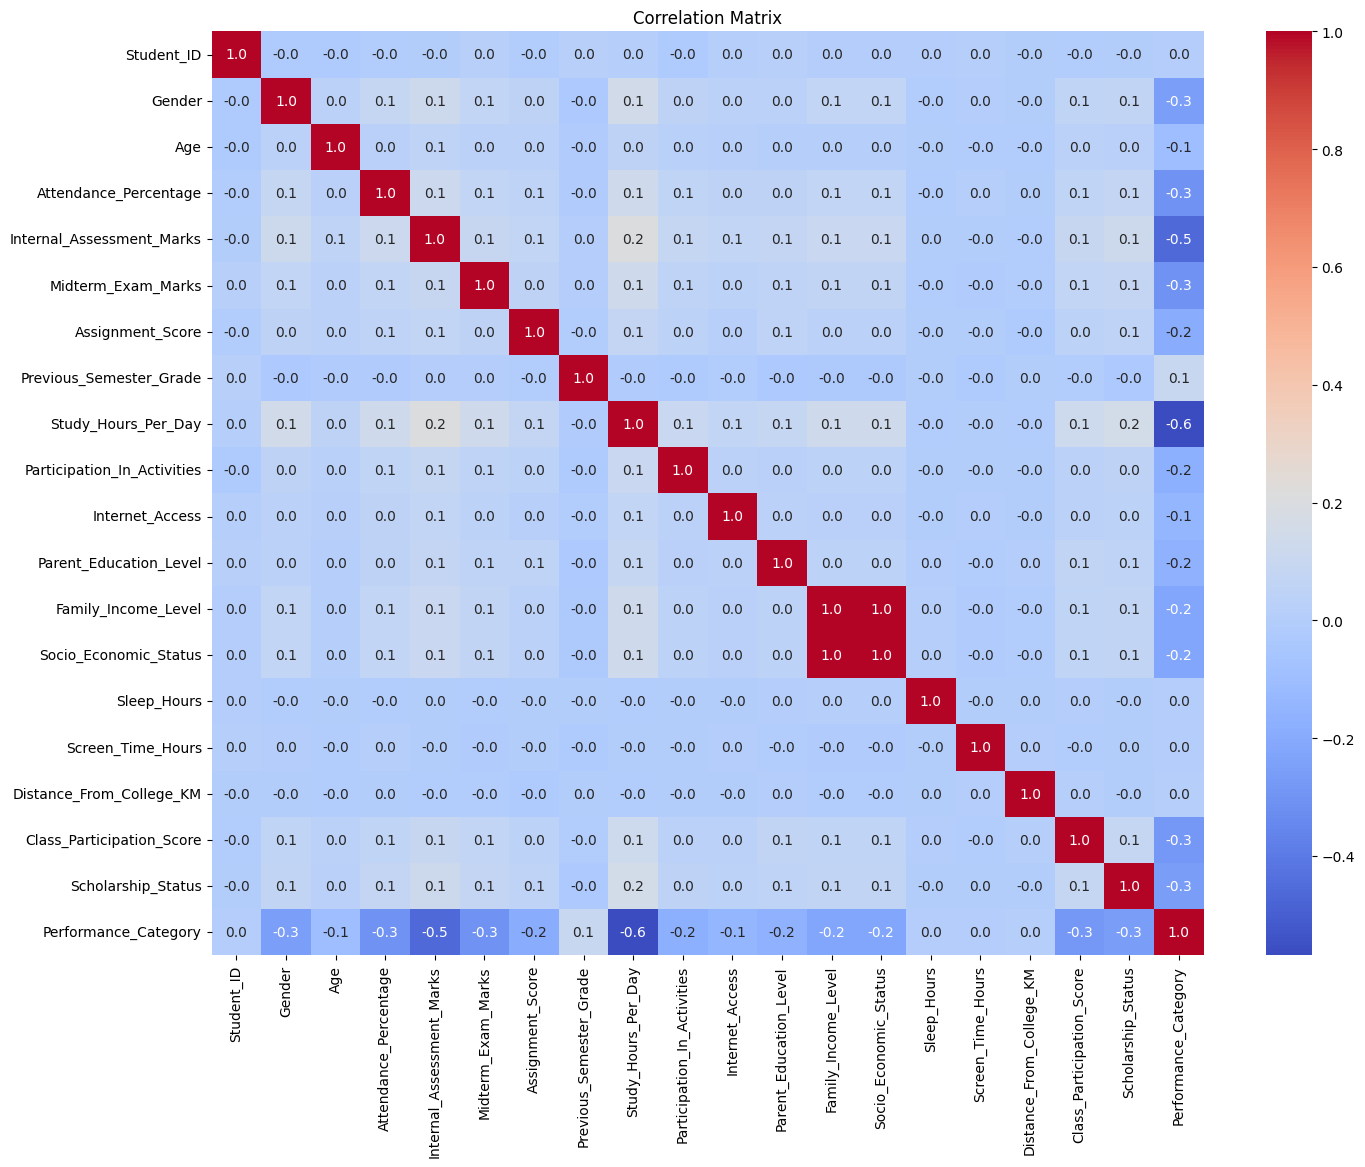

In [ ]:
core_matrix=df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(core_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.drop("Socio_Economic_Status",axis=1,inplace=True)

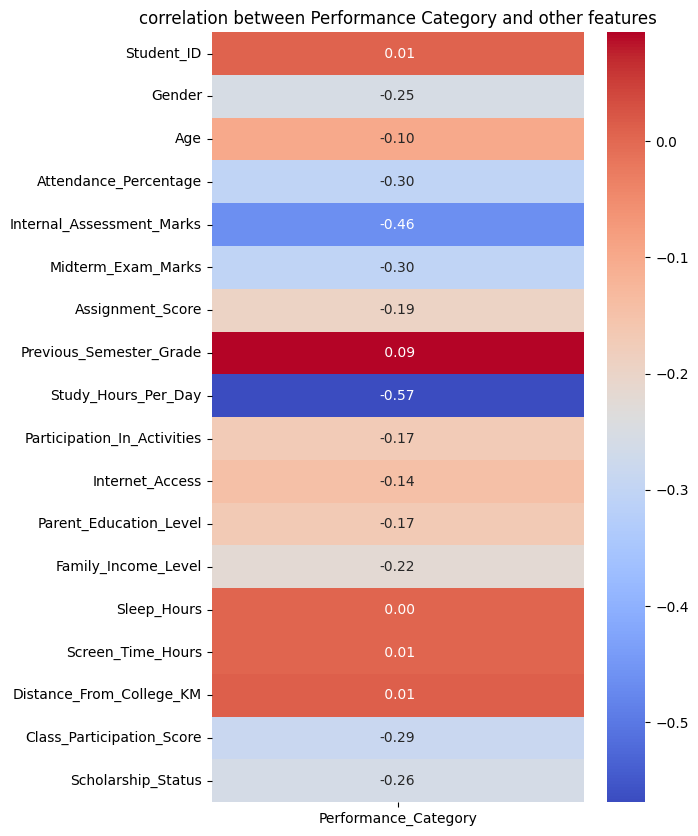

In [ ]:
plt.figure(figsize=(6,10))

status_corr=df.corr()["Performance_Category"]
status_corr=status_corr.drop("Performance_Category")
sns.heatmap(status_corr.to_frame(), annot=True,fmt=' .2f',cmap='coolwarm',cbar=True, annot_kws={'size':10})
plt.title('correlation between Performance Category and other features')
plt.show()

In [ ]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Study_Hours_Per_Day',
       'Participation_In_Activities', 'Internet_Access',
       'Parent_Education_Level', 'Family_Income_Level', 'Sleep_Hours',
       'Screen_Time_Hours', 'Distance_From_College_KM',
       'Class_Participation_Score', 'Scholarship_Status',
       'Performance_Category'],
      dtype='object')

In [ ]:
df.drop(["Sleep_Hours","Study_Hours_Per_Day","Class_Participation_Score"],axis=1,inplace=True)

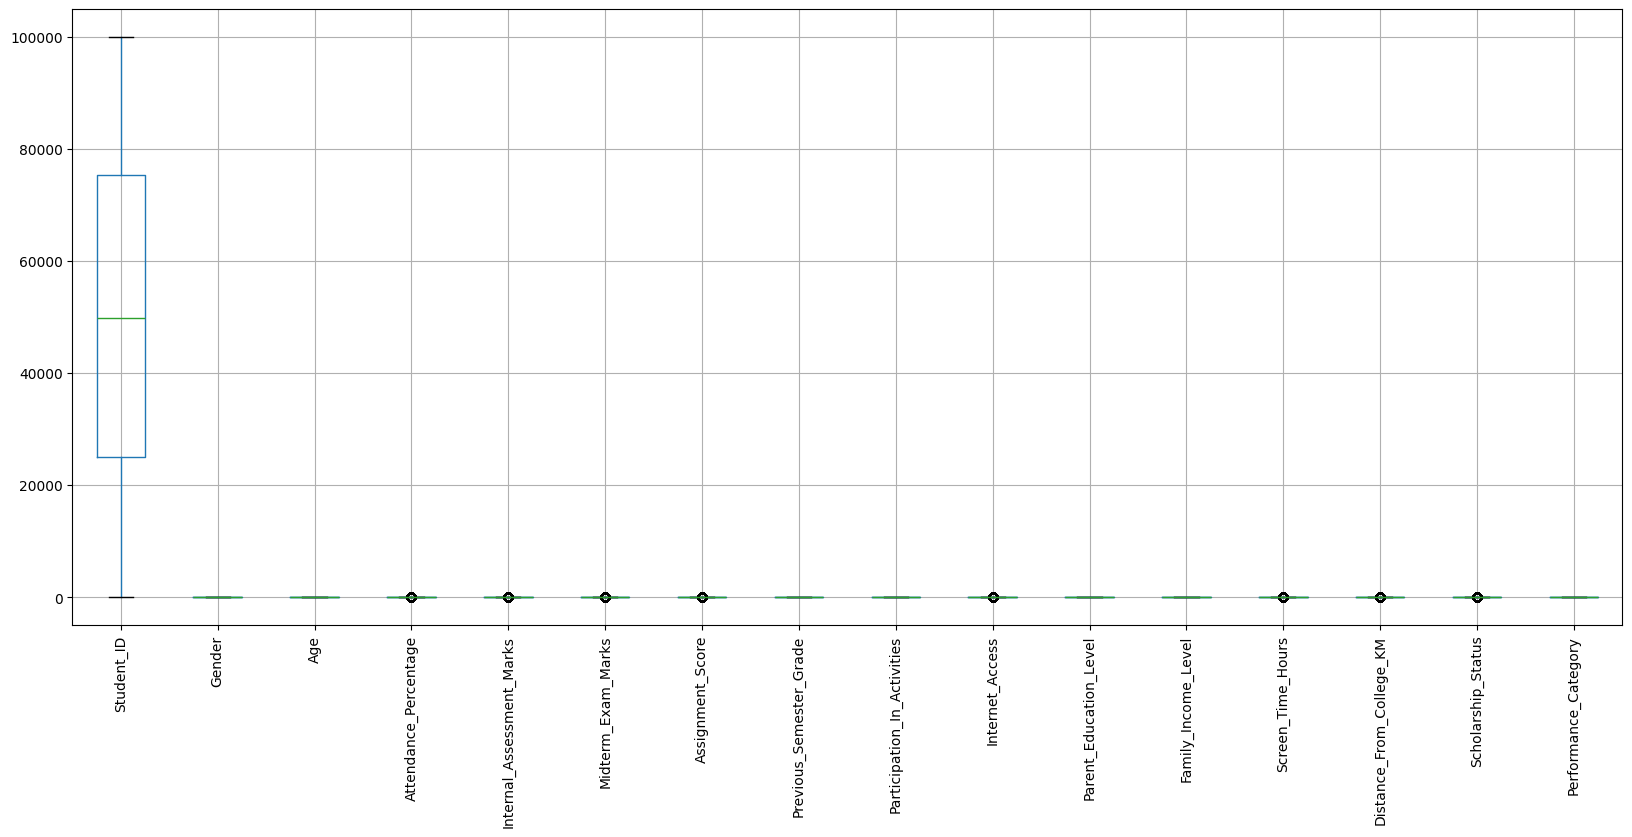

In [ ]:
df.boxplot(figsize=(20,8))
plt.xticks(rotation=90)
plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
    for col in df.select_dtypes(include=['int64','float64']).columns:
        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df
df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.columns

Index(['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Participation_In_Activities',
       'Internet_Access', 'Parent_Education_Level', 'Family_Income_Level',
       'Screen_Time_Hours', 'Distance_From_College_KM', 'Scholarship_Status',
       'Performance_Category'],
      dtype='object')

In [ ]:
features=['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Participation_In_Activities',
       'Internet_Access', 'Parent_Education_Level', 'Family_Income_Level',
       'Screen_Time_Hours', 'Distance_From_College_KM', 'Scholarship_Status' ]
scaler=MinMaxScaler()
scaled_data=scaler.fit_transform(df[features])
scaled_df=pd.DataFrame(scaled_data,columns=features)

In [ ]:
x=df[['Student_ID', 'Gender', 'Age', 'Attendance_Percentage',
       'Internal_Assessment_Marks', 'Midterm_Exam_Marks', 'Assignment_Score',
       'Previous_Semester_Grade', 'Participation_In_Activities',
       'Internet_Access', 'Parent_Education_Level', 'Family_Income_Level',
       'Screen_Time_Hours', 'Distance_From_College_KM', 'Scholarship_Status']]
y=df["Performance_Category"]

x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.25, random_state=42)

model=LogisticRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.70


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Machine Learning

In [ ]:
#DecisionTree

from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.90


In [ ]:
# SVC

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Pipeline Linear SVC Accuracy: {accuracy:.2f}")

Pipeline Linear SVC Accuracy: 0.82


In [ ]:
#Random forest

from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.95


In [ ]:
#GradientBooster

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8724678302968532


In [ ]:
# ADABOOST
from sklearn.ensemble import AdaBoostClassifier

model=AdaBoostClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.84


In [ ]:
#xgboost

from  xgboost import XGBClassifier

model=XGBClassifier()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Baseline model accuracy: {accuracy:.2f}")

Baseline model accuracy: 0.94


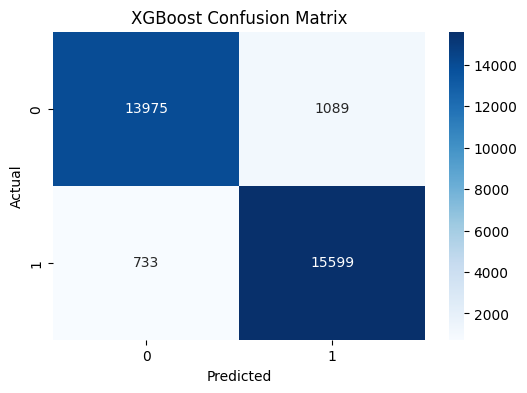

In [ ]:
#Confusion Matrix

cm=confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# K-Fold Cross Validation

In [ ]:
X=df.drop('Performance_Category',axis=1)
y=df['Performance_Category']

kf=KFold(n_splits=5,shuffle=True,random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0
best_fold=-1

best_x_train=None
best_y_train=None
best_x_test=None
best_y_test=None
best_y_pred=None

for fold,(train_index,test_index) in enumerate(kf.split(x),1):

    print(f"\nFold {fold}")

    x_train,x_test=x.iloc[train_index],x.iloc[test_index]
    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(x_train,y_train)

    y_pred=model.predict(x_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc
        best_fold=fold

        best_X_train=x_train
        best_y_train=y_train

        best_X_test=x_test
        best_y_test=y_test

        best_y_pred=y_pred

print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Fold 1


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8156626985706892

Fold 2


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.819922761476291

Fold 3


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8137840420449116

Fold 4


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8160535117056856

Fold 5
Accuracy: 0.817566491479535

Best Fold: 2 with Accuracy: 0.819922761476291


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model=LogisticRegression(max_iter=10000)
model.fit(best_X_train,best_y_train)
print("Logistic Regression:",model.score(best_X_test,best_y_test))

Logistic Regression: 0.819922761476291


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
print("Random Forest:",model.score(best_X_test,best_y_test))

Random Forest: 0.9489588724768085


In [ ]:
model=DecisionTreeClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Decision Tree:",model.score(best_X_test,best_y_test))

Decision Tree: 0.8987140183939165


In [ ]:
model=SVC()
model.fit(best_X_train,best_y_train)
print("SVM:",model.score(best_X_test,best_y_test))

SVM: 0.5260978620058128


In [ ]:
model=GradientBoostingClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("Gradient Boosting:",model.score(best_X_test,best_y_test))

Gradient Boosting: 0.874268423776725


In [ ]:
model=AdaBoostClassifier(random_state=42)
model.fit(best_X_train,best_y_train)
print("AdaBoost:",model.score(best_X_test,best_y_test))

AdaBoost: 0.8439702193733328


In [ ]:
model=XGBClassifier(eval_metric='logloss',random_state=42)
model.fit(best_X_train,best_y_train)
print("XGBoost:",model.score(best_X_test,best_y_test))

XGBoost: 0.9423099892503085


In [ ]:
df.shape

(125582, 16)

# Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define features and target for Deep Learning
X_dl = df.drop('Performance_Category', axis=1)
y_dl = df['Performance_Category']

# Split data into training and testing sets
x_train_dl, x_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.25, random_state=42)

# Scale the features
scaler_dl = StandardScaler()
x_train_scaled_dl = scaler_dl.fit_transform(x_train_dl)
x_test_scaled_dl = scaler_dl.transform(x_test_dl)

model=Sequential()
model.add(Dense(128,input_shape=(x_train_scaled_dl.shape[1],),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer=Adam(),loss='binary_crossentropy',metrics=['accuracy'])

model.fit(x_train_scaled_dl,y_train_dl,epochs=100, verbose=0)

y_pred=model.predict(x_test_scaled_dl)
y_pred=(y_pred>0.5).astype(int)

print(f'\nAccuracy: {accuracy_score(y_test_dl,y_pred)}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


982/982 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Accuracy: 0.9315836412281819


# Conclusion

A comparative analysis was conducted using various machine learning and deep learning algorithms to predict student performance. Among all the models tested, Random Forest achieved the highest accuracy of 94.90%, demonstrating superior predictive capability and robustness in handling complex relationships within the dataset. XGBoost (94.23%) and the Deep Learning model (93.16%) also delivered strong performance, closely following Random Forest. In contrast, Logistic Regression, AdaBoost, Gradient Boosting, and Decision Tree showed moderate performance, while SVM recorded the lowest accuracy of 52.61%. Based on the experimental results, Random Forest is identified as the most suitable model for this study due to its highest classification accuracy and reliable prediction performance.


# Future Scope

The current study can be further enhanced by incorporating larger and more diverse datasets to improve the model's generalization capability and prediction accuracy. Future research may explore advanced deep learning architectures, ensemble techniques, and automated machine learning (AutoML) approaches to achieve better performance. Additional factors such as attendance patterns, behavioral data, learning styles, and real-time academic activities can be integrated to provide more comprehensive predictions. The developed model can also be deployed as a web or mobile-based decision support system to assist educational institutions in identifying at-risk students and implementing timely interventions to improve academic outcomes.
